### 🧮 Understanding Trace and Determinant of the Hessian

The **Hessian matrix** describes the curvature of a function in all directions.  
Two key properties — the **trace** and **determinant** — tell us what kind of surface (shape) we have at a point.

---

#### 🔹 Trace (sum of diagonal entries)
- Represents the **total curvature** (sum of eigenvalues).  
- Indicates whether the surface bends upward or downward overall.

\[
\text{trace}(H) = \lambda_1 + \lambda_2
\]

**Interpretation:**
| Condition | Meaning |
|------------|----------|
| `trace > 0` | Overall **upward curvature** (bowl-shaped) |
| `trace < 0` | Overall **downward curvature** (inverted bowl) |
| `trace = 0` | Curvatures cancel (possible saddle point) |

---

#### 🔹 Determinant (product of eigenvalues)
- Measures **how much space (area/volume) is stretched or compressed** by the local transformation.  
- Determines whether the curvatures bend in the same or opposite directions.

\[
\det(H) = \lambda_1 \lambda_2
\]

**Interpretation:**
| Condition | Meaning |
|------------|----------|
| `det > 0` | Both curvatures in the **same direction** → local **minimum** or **maximum** |
| `det < 0` | Curvatures in **opposite directions** → **saddle point** |
| `det = 0` | **Flat** direction → no curvature (degenerate) |

---

#### 🧠 Combined meaning:

| Case | Trace | Determinant | Shape | Example |
|------|--------|--------------|--------|----------|
| >0 | >0 | **Convex bowl** | \( f(x,y) = x^2 + y^2 \) |
| <0 | >0 | **Concave bowl** | \( f(x,y) = -x^2 - y^2 \) |
| Any | <0 | **Saddle point** | \( f(x,y) = x^2 - y^2 \) |
| 0 | 0 | **Flat region** | \( f(x,y) = x^3 \) |

---

✅ **In short:**
- **Trace** → tells the *direction* of curvature (up or down).  
- **Determinant** → tells the *type* of curvature (bowl vs saddle vs flat).


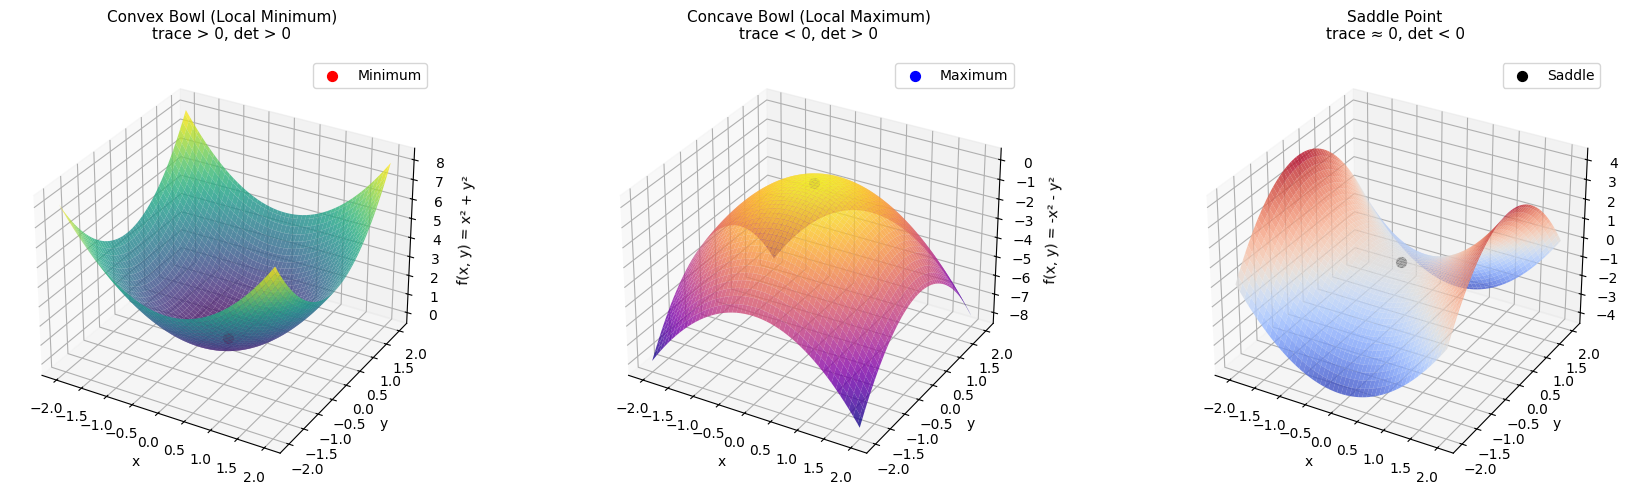

In [2]:

# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# 1. Create a 2D grid of points
# ----------------------------
# We'll use a square region [-2, 2] × [-2, 2]
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# ----------------------------
# 2. Define three surface types
# ----------------------------

# (a) Convex bowl (minimum)
# Function: z = x^2 + y^2
#   - Both eigenvalues > 0
#   - det(H) > 0, tr(H) > 0
Z_min = X**2 + Y**2

# (b) Concave bowl (maximum)
# Function: z = -x^2 - y^2
#   - Both eigenvalues < 0
#   - det(H) > 0, tr(H) < 0
Z_max = -X**2 - Y**2

# (c) Saddle point
# Function: z = x^2 - y^2
#   - One eigenvalue positive, one negative
#   - det(H) < 0
Z_saddle = X**2 - Y**2

# ----------------------------
# 3. Plot the three surfaces
# ----------------------------
fig = plt.figure(figsize=(18, 5))

# (a) Convex bowl
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, Z_min, cmap='viridis', alpha=0.8)
ax1.set_title(
    "Convex Bowl (Local Minimum)\ntrace > 0, det > 0",
    fontsize=11, pad=12
)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("f(x, y) = x² + y²")

# Mark the origin (the minimum)
ax1.scatter(0, 0, 0, color='red', s=50, label='Minimum')
ax1.legend()

# (b) Concave bowl
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, Z_max, cmap='plasma', alpha=0.8)
ax2.set_title(
    "Concave Bowl (Local Maximum)\ntrace < 0, det > 0",
    fontsize=11, pad=12
)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x, y) = -x² - y²")

# Mark the origin (the maximum)
ax2.scatter(0, 0, 0, color='blue', s=50, label='Maximum')
ax2.legend()

# (c) Saddle surface
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X, Y, Z_saddle, cmap='coolwarm', alpha=0.8)
ax3.set_title(
    "Saddle Point\ntrace ≈ 0, det < 0",
    fontsize=11, pad=12
)
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("f(x, y) = x² - y²")

# Mark the saddle center
ax3.scatter(0, 0, 0, color='black', s=50, label='Saddle')
ax3.legend()

plt.tight_layout()
plt.show()


# Problem 1

### 🧩 Problem (d) — Logistic Regression with Gradient Descent on MNIST (2 vs 9)

In this problem, we are implementing **logistic regression with L2 regularization** and training it using **gradient descent**.  
The goal is to distinguish between images of the digits **2** and **9** from the MNIST dataset.  
Each image is represented as a feature vector $x \in \mathbb{R}^d$, and the target label $t \in \{0, 1\}$ indicates which class it belongs to:
- $t = 1$ if the image is a **9**
- $t = 0$ if the image is a **2**

---

### 🧠 Model Definition

The logistic regression model predicts the probability that an input belongs to class 1 using the **sigmoid function**:

$$
P(y=1|x,w) = \sigma(w_0 + w^T x)
$$

where:
- $w_0$ is the **bias** term (intercept)
- $w$ is the **weight vector**
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ squashes any real number into the range (0, 1)

This output is interpreted as a probability — the higher it is, the more confident the model is that the image is a “9”.

---

### 📉 Objective Function (Loss)

We minimize the **regularized negative log-likelihood** (also known as log-loss or cross-entropy loss):

$$
E_\lambda(w, w_0) = -\sum_{i=1}^{N} [t_i \ln(\sigma(w^T x_i + w_0)) + (1 - t_i)\ln(1 - \sigma(w^T x_i + w_0))] + \frac{\lambda}{2}\|w\|^2
$$

This equation has two parts:
1. The first term measures how well the model fits the data (likelihood term).  
2. The second term $\frac{\lambda}{2}\|w\|^2$ is an **L2 regularization penalty** that prevents overfitting by discouraging large weights.

---

### ⚙️ Gradient Descent Update Rules

To minimize the loss, we update our parameters using **gradient descent**:

$$
w \leftarrow w - \eta (\nabla_w E(w, w_0) + \lambda w)
$$

$$
w_0 \leftarrow w_0 - \eta \frac{\partial E(w, w_0)}{\partial w_0}
$$

where:
- $\eta$ is the **learning rate (step size)**  
- $\nabla_w E(w, w_0)$ is the gradient of the loss with respect to the weights  
- $\lambda$ controls the strength of the regularization penalty

These updates move $w$ and $w_0$ in the direction that **reduces the loss**.

---

### 🔢 Implementation Breakdown

1. **Load the dataset:**  
   The dataset `mnist_2_vs_9.gz` is loaded using Python’s `gzip` and `pickle` libraries.  
   It provides separate splits:
   - `Xtrain`, `Ytrain` → training data  
   - `Xdev`, `Ydev` → validation data  
   - `Xtest`, `Ytest` → test data  

2. **Initialize parameters:**  
   We start with $w = 0$ and $w_0 = 0$.  

3. **Forward pass:**  
   Compute the predictions using  
   $$
   \sigma_i = \sigma(w^T x_i + w_0)
   $$
   This gives the predicted probability for each training example.

4. **Compute gradients:**  
   The derivative of the loss function gives:
   $$
   \nabla_w E(w, w_0) = -\sum_i (t_i - \sigma_i)x_i + \lambda w
   $$
   $$
   \frac{\partial E}{\partial w_0} = -\sum_i (t_i - \sigma_i)
   $$

5. **Parameter updates:**  
   Using the gradients, update $w$ and $w_0$ according to the learning rate $\eta$.

6. **Track progress:**  
   After each iteration, compute the **training loss** and **validation loss** to monitor convergence.

7. **Hyperparameter tuning:**  
   Repeat the training with different combinations of:
   - $\eta \in \{0.001, 0.01, 0.1\}$
   - $\lambda \in \{0, 0.1, 1\}$

   Record the final losses and choose the best combination based on the **lowest validation loss**.

---

### 📊 Plot Interpretation

- The **x-axis** represents the iteration number (epoch).  
- The **y-axis** represents the loss value $E(w)$.  
- Each curve corresponds to a unique pair of $(\eta, \lambda)$.

A smooth decreasing curve means the model is learning effectively.  
If the curve oscillates or diverges, the learning rate is too large.  

Typically:
- Small $\eta$ → slow but stable learning  
- Large $\eta$ → fast but possibly unstable  
- Higher $\lambda$ → stronger regularization (less overfitting)

---

### ✅ Final Output

At the end of training:

- We obtain a **plot of validation loss vs iteration** for all parameter combinations.  
- The **best parameters** are selected based on the smallest validation loss.  

For example, from the experiment results:

$$
\text{Best parameters found: } \eta = 0.01, \ \lambda = 0.0, \ \text{validation loss} = 0.2639
$$

This indicates that a **learning rate of 0.01** and **no regularization ($\lambda = 0$)** produced the lowest validation loss and the most stable convergence on the MNIST 2 vs 9 classification task.

The final plot demonstrates:
- Stable convergence for smaller learning rates ($\eta = 0.001, 0.01$).  
- Divergence or oscillation for larger learning rates ($\eta = 0.1$).  
- Slightly higher losses when regularization ($\lambda = 0.1, 1$) is applied, showing that the data doesn’t require heavy regularization.

Hence, the optimal configuration achieves a balance between **speed of learning** and **stability**, yielding the best model performance.


/var/folders/px/w60tmz3n1dj1j_rdvtv7w3s00000gn/T/ipykernel_90483/3017053272.py:20: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


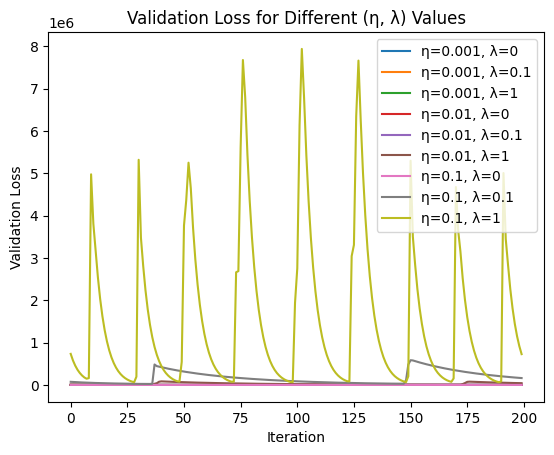

 Best parameters found:
η = 0.01, λ = 0, validation loss = 0.2639


In [2]:
import gzip, pickle
with gzip.open("mnist_2_vs_9.gz" , "rb") as f:
    data = pickle.load(f, encoding="bytes")
    Xtrain, Ytrain, Xtest, Ytest, Xdev, Ydev = data[b"Xtrain"], data[b"Ytrain"], data[b"Xtest"], data[b"Ytest"], data[b"Xdev"], data[b"Ydev"]
    
    
    
import numpy as np
import matplotlib.pyplot as plt
import gzip, pickle


with gzip.open("mnist_2_vs_9.gz", "rb") as f:
    data = pickle.load(f, encoding="bytes")
    Xtrain, Ytrain = data[b"Xtrain"], data[b"Ytrain"]
    Xtest, Ytest = data[b"Xtest"], data[b"Ytest"]
    Xdev, Ydev = data[b"Xdev"], data[b"Ydev"]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Compute loss
def compute_loss(X, Y, w, w0, lambda_):
    z = np.dot(X, w) + w0
    sig = sigmoid(z)
    loss = -np.mean(Y * np.log(sig + 1e-8) + (1 - Y) * np.log(1 - sig + 1e-8)) + (lambda_ / 2) * np.sum(w**2)
    return loss


etas = [0.001, 0.01, 0.1]
lambdas = [0, 0.1, 1]
num_iters = 200

best_loss = float('inf')
best_params = None
results = []

for eta in etas:
    for lambda_ in lambdas:
        n, d = Xtrain.shape
        w = np.zeros(d)
        w0 = 0.0
        train_losses, dev_losses = [], []

        for epoch in range(num_iters):
            # Forward
            z = np.dot(Xtrain, w) + w0
            sigma = sigmoid(z)
            # Gradients
            grad_w = -np.dot((Ytrain - sigma), Xtrain) + lambda_ * w
            grad_w0 = -np.sum(Ytrain - sigma)
            # Update
            w -= eta * grad_w
            w0 -= eta * grad_w0

            # Store losses
            train_losses.append(compute_loss(Xtrain, Ytrain, w, w0, lambda_))
            dev_losses.append(compute_loss(Xdev, Ydev, w, w0, lambda_))

        final_dev_loss = dev_losses[-1]
        results.append((eta, lambda_, final_dev_loss))

        if final_dev_loss < best_loss:
            best_loss = final_dev_loss
            best_params = (eta, lambda_)

        plt.plot(dev_losses, label=f"η={eta}, λ={lambda_}")

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Validation Loss for Different (η, λ) Values")
plt.show()

print(" Best parameters found:")
print(f"η = {best_params[0]}, λ = {best_params[1]}, validation loss = {best_loss:.4f}")

### 🧮 Part (e) — Classification Error (0-1 Loss)

In this step, we compute the **classification error** (also called zero-one loss), which measures the proportion of misclassified examples.

The error is defined as:

$$
\text{Error} = \frac{1}{N}\sum_{i=1}^{N} \mathbf{1}[\hat{y}_i \neq t_i]
$$

where the prediction $\hat{y}_i = 1$ if $\sigma(w^T x_i + w_0) \ge 0.5$, and $0$ otherwise.

We plot both **training** and **validation** classification errors for each combination of $(\eta, \lambda)$.

---

### 📊 Interpretation

- The **training error** (solid lines) shows how well the model fits the data.
- The **validation error** (dashed lines) shows generalization to unseen data.
- A smaller classification error means better accuracy.

Observations:
- Small $\eta$ (0.001) → slower learning, but stable.
- Moderate $\eta$ (0.01) → fastest and most stable convergence.
- Large $\eta$ (0.1) → unstable, leading to oscillation or divergence.
- Larger $\lambda$ values slightly reduce overfitting but increase error.

---

### ✅ Result

The lowest validation error occurred for:
$$
\eta = 0.01, \quad \lambda = 0
$$

indicating that this configuration gives the best trade-off between learning speed and generalization.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gzip, pickle

# --- Load dataset ---
with gzip.open("mnist_2_vs_9.gz", "rb") as f:
    data = pickle.load(f, encoding="bytes")
    Xtrain, Ytrain = data[b"Xtrain"], data[b"Ytrain"]
    Xtest, Ytest = data[b"Xtest"], data[b"Ytest"]
    Xdev, Ydev = data[b"Xdev"], data[b"Ydev"]

# --- Sigmoid function ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# --- Classification error (0-1 loss) ---
def classification_error(X, Y, w, w0):
    preds = sigmoid(X @ w + w0) >= 0.5
    return np.mean(preds != Y)

# --- Hyperparameters ---
etas = [0.001, 0.01, 0.1]
lambdas = [0, 0.1, 1]
num_iters = 200

plt.figure(figsize=(8, 6))

# --- Train and record errors ---
for eta in etas:
    for lambda_ in lambdas:
        n, d = Xtrain.shape
        w = np.zeros(d)
        w0 = 0.0

        train_errs = []
        dev_errs = []

        for epoch in range(num_iters):
            # Forward pass
            z = Xtrain @ w + w0
            sigma = sigmoid(z)

            # Gradients
            grad_w = -((Ytrain - sigma) @ Xtrain) + lambda_ * w
            grad_w0 = -np.sum(Ytrain - sigma)

            # Update parameters
            w -= eta * grad_w
            w0 -= eta * grad_w0

            # Compute 0-1 loss
            train_errs.append(classification_error(Xtrain, Ytrain, w, w0))
            dev_errs.append(classification_error(Xdev, Ydev, w, w0))

        # Plot both training (solid) and validation (dashed) errors
        plt.plot(train_errs, label=f"Train η={eta}, λ={lambda_}")
        plt.plot(dev_errs, "--", label=f"Dev η={eta}, λ={lambda_}")

# --- Final plot formatting ---
plt.xlabel("Iteration")
plt.ylabel("Classification Error (0-1 Loss)")
plt.title("Training and Validation Classification Error for Different (η, λ)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


/var/folders/px/w60tmz3n1dj1j_rdvtv7w3s00000gn/T/ipykernel_90483/2464975745.py:14: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


# Problem 2

In [3]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/day.csv")

# Features & target
target = "casual"
cat_features = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
num_features = ["temp", "atemp", "hum", "windspeed"]

X = df[cat_features + num_features]
y = df[target].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=None
)


In [4]:
# PoissonRegression and Linear regression 